# Cafe Sales: Data Cleaning and Visualization

This notebook demonstrates the end-to-end process of turning a messy dataset into an analysis and visualization-ready format. 

**Core Objectives:**
1. Standardize missing or corrupted data (e.g., converting "UNKNOWN" and "ERROR" to `NA`).
2. Programmatically impute missing values using known mathematical relationships (Total = Quantity * Price) and deterministic rules.
3. Clean data types and drop unrecoverable records.
4. Launch an interactive visualisation environment.

In [221]:
## Setup and Data Loading
library(readr)
library(tidyverse)
library(lubridate)

# Load the dataset
rawdata <- read.csv('dirty_cafe_sales.csv')

# Initial peek at the dataset
head(rawdata)

# Looking at unique values for each column.
lapply(rawdata[,-1], unique)

$Item
 [1] "Coffee"   "Cake"     "Cookie"   "Salad"    "Smoothie" "UNKNOWN"  "Sandwich" ""         "ERROR"    "Juice"    "Tea"     

$Quantity
[1] "2"       "4"       "5"       "3"       "1"       "ERROR"   "UNKNOWN" ""       

$Price.Per.Unit
[1] "2.0"     "3.0"     "1.0"     "5.0"     "4.0"     "1.5"     ""        "ERROR"   "UNKNOWN"

$Total.Spent
 [1] "4.0"     "12.0"    "ERROR"   "10.0"    "20.0"    "9.0"     "16.0"    "15.0"    "25.0"    "8.0"     "5.0"     "3.0"     "6.0"    
[14] ""        "UNKNOWN" "2.0"     "1.0"     "7.5"     "4.5"     "1.5"    

$Payment.Method
[1] "Credit Card"    "Cash"           "UNKNOWN"        "Digital Wallet" "ERROR"          ""              

$Location
[1] "Takeaway" "In-store" "UNKNOWN"  ""         "ERROR"   

$Transaction.Date
  [1] "2023-09-08" "2023-05-16" "2023-07-19" "2023-04-27" "2023-06-11" "2023-03-31" "2023-10-06" "2023-10-28" "2023-07-28" "2023-12-31"
 [11] "2023-11-07" "ERROR"      "2023-05-03" "2023-06-01" "2023-03-21" "2023-11-15" "2023-

## 2. Standardizing Missing Values
After initial inspection, the dataset contains missing values represented in three ways: empty strings `""`, `"UNKNOWN"`, and `"ERROR"`. 

To utilize R's built-in `NA` handling mechanics, we must first convert all these messy representations into standard `NA` values across the entire dataframe.

In [222]:
# Define the strings that represent missing/bad data
bad_values <- c("", "ERROR", "UNKNOWN")

# We use dplyr::mutate with across() to efficiently scan every column 
# and replace the bad values with NA, rather than using a standard for-loop.
rawdata <- rawdata %>%
  mutate(across(everything(), ~ if_else(. %in% bad_values, NA, .)))

# Verify the changes by checking for remaining unique values
lapply(rawdata[,-1], unique)

$Item
[1] "Coffee"   "Cake"     "Cookie"   "Salad"    "Smoothie" NA         "Sandwich" "Juice"    "Tea"     

$Quantity
[1] "2" "4" "5" "3" "1" NA 

$Price.Per.Unit
[1] "2.0" "3.0" "1.0" "5.0" "4.0" "1.5" NA   

$Total.Spent
 [1] "4.0"  "12.0" NA     "10.0" "20.0" "9.0"  "16.0" "15.0" "25.0" "8.0"  "5.0"  "3.0"  "6.0"  "2.0"  "1.0"  "7.5"  "4.5"  "1.5" 

$Payment.Method
[1] "Credit Card"    "Cash"           NA               "Digital Wallet"

$Location
[1] "Takeaway" "In-store" NA        

$Transaction.Date
  [1] "2023-09-08" "2023-05-16" "2023-07-19" "2023-04-27" "2023-06-11" "2023-03-31" "2023-10-06" "2023-10-28" "2023-07-28" "2023-12-31"
 [11] "2023-11-07" NA           "2023-05-03" "2023-06-01" "2023-03-21" "2023-11-15" "2023-06-10" "2023-02-24" "2023-03-25" "2023-01-15"
 [21] "2023-04-04" "2023-03-30" "2023-12-01" "2023-09-18" "2023-06-03" "2023-12-13" "2023-04-20" "2023-04-10" "2023-03-11" "2023-06-02"
 [31] "2023-11-06" "2023-08-15" "2023-10-09" "2023-05-28" "2023-07-17" "2023-04-

## 3. Data Imputation
Many rows contain missing data that can be logically deduced:
* **Prices:** Can be calculated if we know Total Spent and Quantity.
* **Items:** Certain prices map uniquely to specific items (e.g., $1.0 is always a Cookie).
* **Totals & Quantities:** Can be solved algebraically if the other two variables are known.

**Note on Ambiguous Items:** Cake/Juice ($3.0) and Smoothie/Sandwich ($4.0) share prices. If an item is missing but the price is known, we will impute the item probabilistically using a random sample.

In [223]:
set.seed(42)  # Ensure our random sampling for ambiguous items is reproducible

rawdata <- rawdata %>%
  # Step A: Convert target columns to numeric before doing any math
  mutate(
    Item = as.factor(Item),
    Quantity = as.numeric(Quantity),
    Price.Per.Unit = as.numeric(Price.Per.Unit),
    Total.Spent = as.numeric(Total.Spent)
  ) %>%
  mutate(
    # Step B: Objective Math. If Price is missing, but we have Total and Qty, calculate it.
    # If math isn't possible, use the known item names to fill in the standard prices.
    Price.Per.Unit_new = case_when(
      is.na(Price.Per.Unit) & !is.na(Total.Spent) & !is.na(Quantity) ~ Total.Spent / Quantity,
      is.na(Price.Per.Unit) & Item == 'Cookie' ~ 1.0,
      is.na(Price.Per.Unit) & Item == 'Tea' ~ 1.5,
      is.na(Price.Per.Unit) & Item == 'Coffee' ~ 2.0,
      is.na(Price.Per.Unit) & Item %in% c('Cake', 'Juice') ~ 3.0,
      is.na(Price.Per.Unit) & Item %in% c('Smoothie', 'Sandwich') ~ 4.0,
      is.na(Price.Per.Unit) & Item == 'Salad' ~ 5.0,
      TRUE ~ Price.Per.Unit
    ),
    
    # Step C: Infer Missing Items. Now that prices are populated, map them back to items.
    # We reference the newly created 'Price.Per.Unit_new' column here.
    Item_new = case_when(
      Price.Per.Unit_new == 1.0 ~ "Cookie",
      Price.Per.Unit_new == 1.5 ~ "Tea",
      Price.Per.Unit_new == 2.0 ~ "Coffee",
      Price.Per.Unit_new == 5.0 ~ "Salad",
      # Probabilistic imputation for shared price points
      is.na(Item) & Price.Per.Unit_new == 3.0 ~ sample(c("Cake", "Juice"), n(), replace = TRUE),
      is.na(Item) & Price.Per.Unit_new == 4.0 ~ sample(c("Smoothie", "Sandwich"), n(), replace = TRUE),
      TRUE ~ Item
    ),

    # Step D: Fill in remaining math for Quantity and Total Spent
    Quantity_new = case_when(
      is.na(Quantity) ~ Total.Spent / Price.Per.Unit_new,
      TRUE ~ Quantity
    ),
    Total.Spent_new = case_when(
      is.na(Total.Spent) ~ Price.Per.Unit_new * Quantity_new,
      TRUE ~ Total.Spent
    )
  )

## Still some NAs remaining, check further
bad_entries <- rawdata %>% filter(is.na(Item_new)|
  is.na(Quantity_new)|
  is.na(Price.Per.Unit_new)|
  is.na(Total.Spent_new))

bad_entries

   Transaction.ID     Item Quantity Price.Per.Unit Total.Spent Payment.Method Location Transaction.Date Price.Per.Unit_new Item_new
1     TXN_8562645    Salad       NA            5.0          NA           <NA> In-store       2023-05-18                5.0    Salad
2     TXN_3229409    Juice       NA            3.0          NA           Cash Takeaway       2023-04-15                3.0    Juice
3     TXN_2962976    Juice       NA            3.0          NA           <NA>     <NA>       2023-03-17                3.0    Juice
4     TXN_8696094 Sandwich       NA            4.0          NA           <NA> Takeaway       2023-05-14                4.0 Sandwich
5     TXN_3611851     <NA>        4             NA          NA    Credit Card     <NA>       2023-02-09                 NA     <NA>
6     TXN_7524977     <NA>        4             NA          NA           <NA>     <NA>       2023-12-09                 NA     <NA>
7     TXN_9188692     Cake       NA            3.0          NA    Credit Car

## 4. Final Cleanup: Dropping unrecoverable records & Formatting
There are roughly 26 rows where 2 or more variables were missing, making computation impossible. Because this represents a tiny fraction of our data, we will drop them. 

Finally, we will replace the original messy columns with our newly imputed columns and convert the `Transaction.Date` column to a proper Date object.

In [220]:
rawdata_clean <- rawdata %>% 
  # Drop rows that still have NAs in our completed columns
  filter(
    !is.na(Item_new),
    !is.na(Quantity_new),
    !is.na(Price.Per.Unit_new),
    !is.na(Total.Spent_new)
  ) %>%
  # Parse dates
  mutate(Transaction.Date = ymd(Transaction.Date)) %>%
  # Overwrite original columns with the clean '_new' columns and drop the old ones
  # Using select() by name is safer than using numeric indices like `[,c(1,9:12)]`
  select(
    Transaction.ID = 1, # Keeps the first column as the ID
    Item = Item_new,
    Quantity = Quantity_new,
    Price.Per.Unit = Price.Per.Unit_new,
    Total.Spent = Total.Spent_new,
    Payment.Method,
    Location,
    Transaction.Date
  )

# Verify final clean data
head(rawdata_clean)

  Transaction.ID     Item Quantity Price.Per.Unit Total.Spent Payment.Method Location Transaction.Date
1    TXN_1961373   Coffee        2              2           4    Credit Card Takeaway       2023-09-08
2    TXN_4977031     Cake        4              3          12           Cash In-store       2023-05-16
3    TXN_4271903   Cookie        4              1           4    Credit Card In-store       2023-07-19
4    TXN_7034554    Salad        2              5          10           <NA>     <NA>       2023-04-27
5    TXN_3160411   Coffee        2              2           4 Digital Wallet In-store       2023-06-11
6    TXN_2602893 Smoothie        5              4          20    Credit Card     <NA>       2023-03-31

## 5. Interactive Visualizations
Launch the `esquisse` UI tool to build `ggplot2` graphs dynamically.

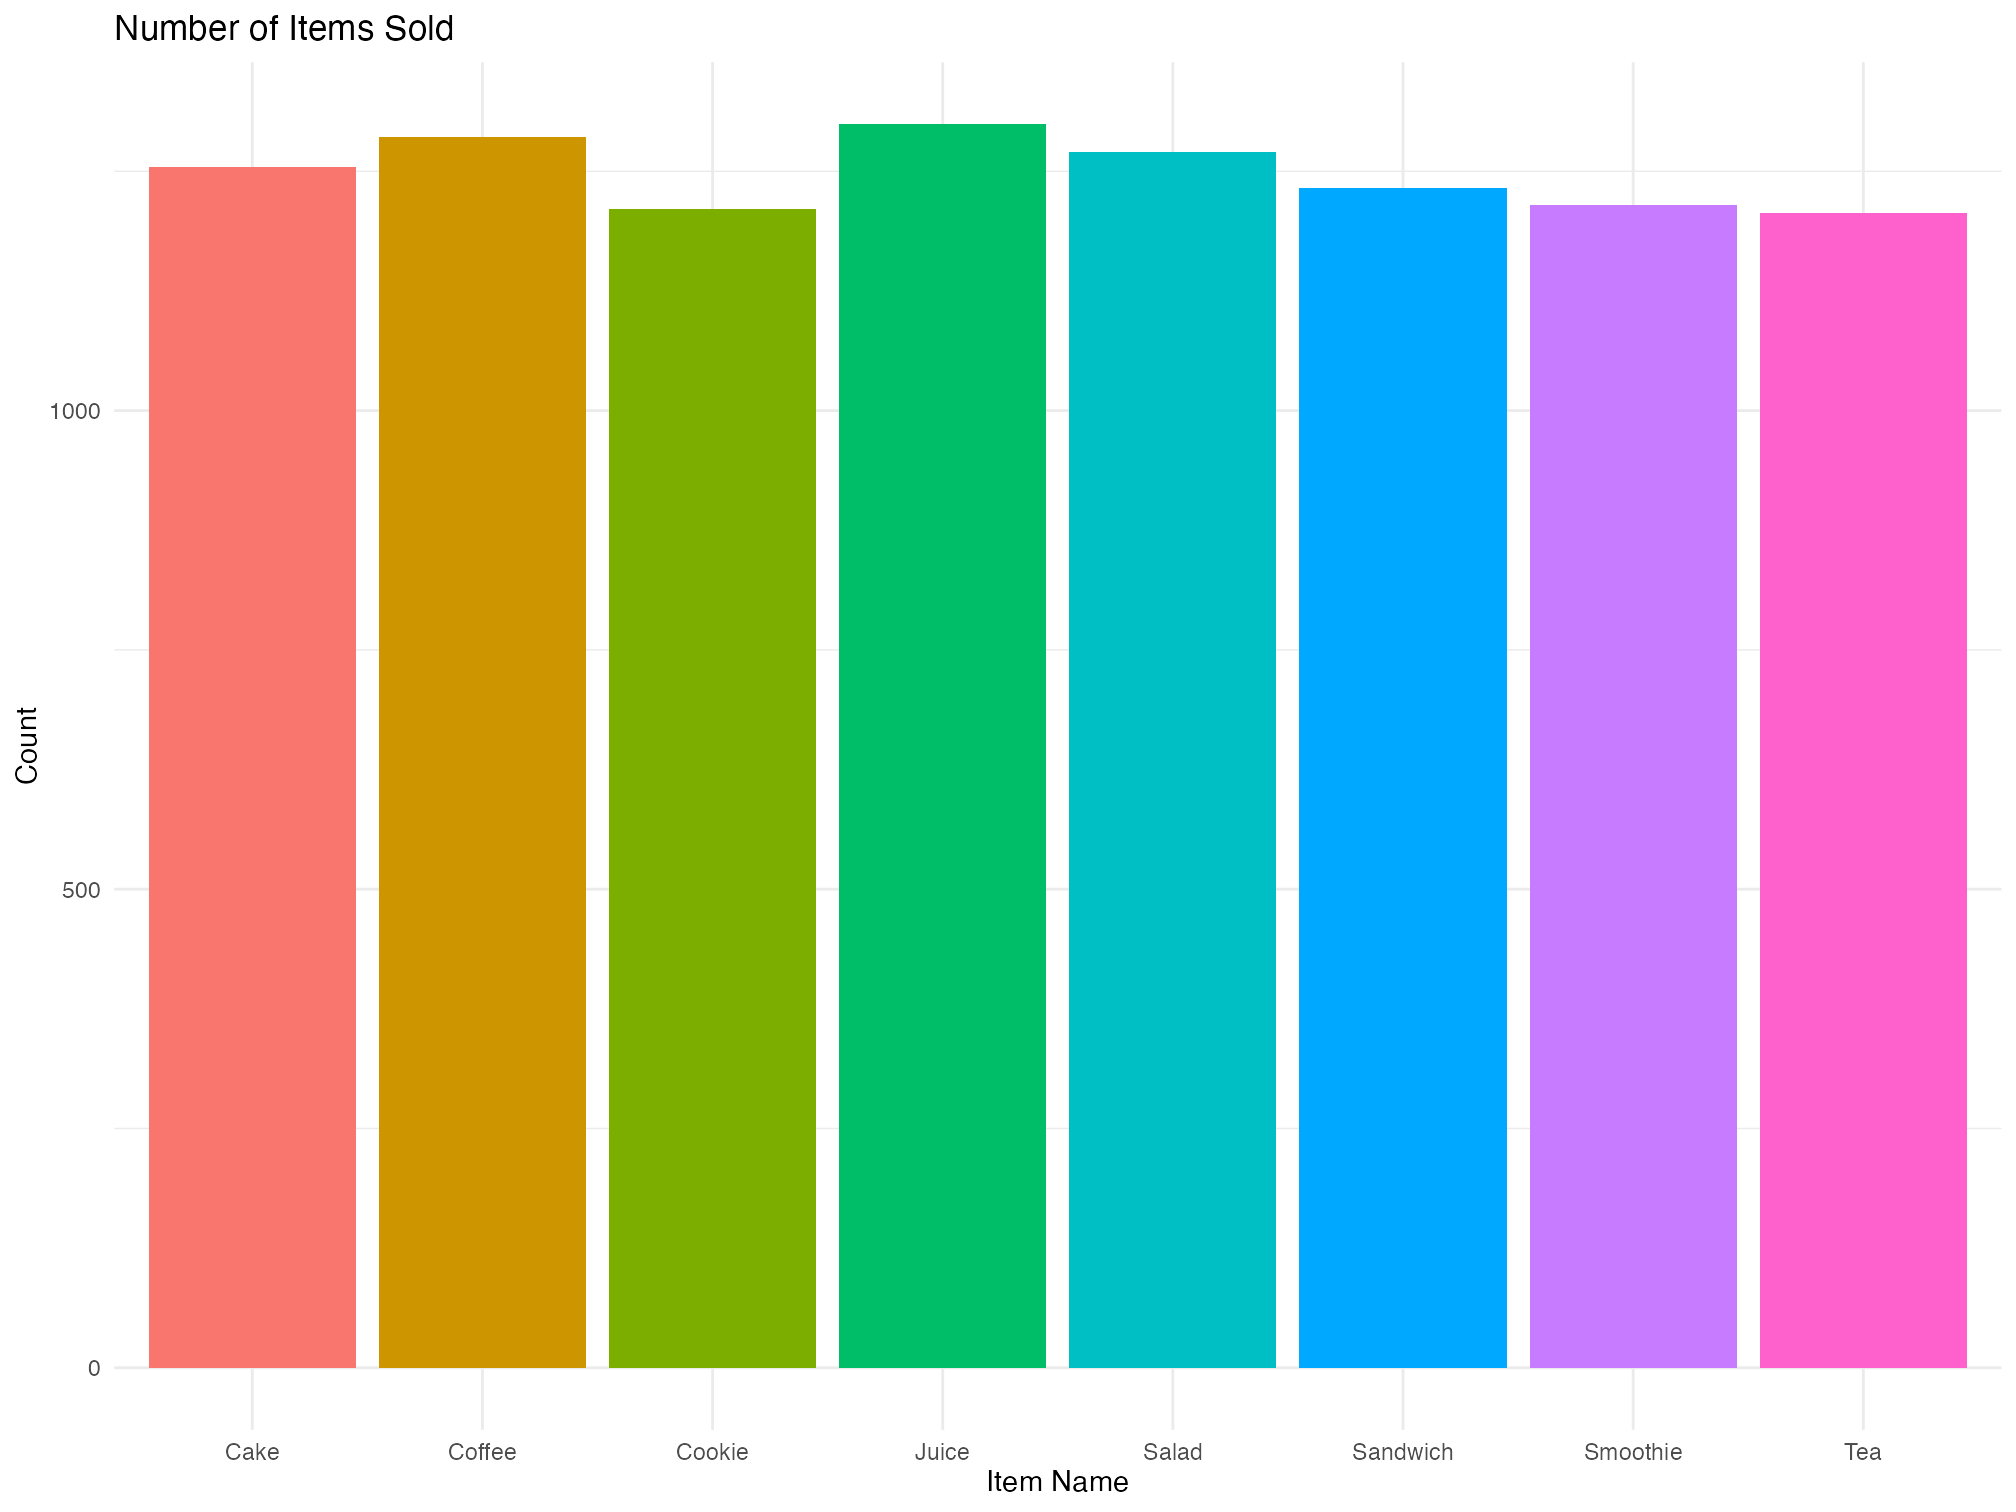

In [ ]:
library(ggplot2)

# Building a bar chart layer by layer
ggplot(data = rawdata_clean, aes(x = Item, fill = Item)) +
  geom_bar() +                               
  
  theme_minimal() +                           
  labs(title = "Number of Items Sold",        
       x = "Item Name", 
       y = "Count") +
  theme(legend.position = "none")             